In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LassoCV

In [13]:
sns.get_dataset_names()
penguins = sns.load_dataset("penguins")
print(penguins.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


<Axes: xlabel='species', ylabel='body_mass_g'>

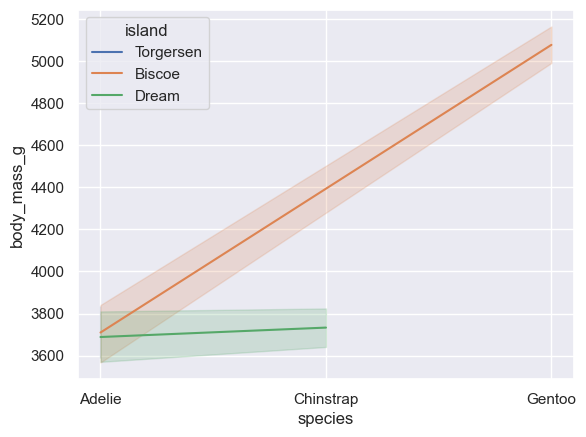

In [15]:
sns.lineplot(
    data = penguins,
    x = "species",
    y = "body_mass_g",
    hue = "island"
)

In [31]:
# encoding...
penguins = penguins.dropna()
x = penguins.drop(columns="body_mass_g")
y = penguins["body_mass_g"]

# Correct mapping
x["sex"] = x["sex"].map({"Female": 1, "Male": 0})

# One-hot encoding
x = pd.get_dummies(
    x,
    columns=["species", "island"],
    drop_first=True,
    dtype=int
)
# split the data..
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state = 42
)


In [32]:
print(y_train.head())

230    4650.0
84     3350.0
303    5350.0
22     3800.0
29     3950.0
Name: body_mass_g, dtype: float64


In [33]:
model = LinearRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

r2 = r2_score(y_test,y_pred)
print(" r squared value is : ",r2)

 r squared value is :  0.8961688345769455
